# MBAR 

Updated: 12/21/2024 

By: van

In [1]:
!printf "This notebook is found in...\n$(echo $(realpath .))"

This notebook is found in...
/scratch/van/ippoi/qmmm/h98q/mbar

In [2]:
import os
import sys
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
#from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter
# plt.style.use('/home/van/Scripts/bin/v.mplstyle')
import seaborn as sb
from glob import glob
from sklearn.utils import resample

import pymbar
from pymbar.mbar_pmf import mbar_pmf

In [3]:
os.makedirs('img', exist_ok=True)

In [4]:
# CV file from {step}.{rep}_equilibration.cv
step="step5"
rep="00"

n_windows = 42
val_min = -1.10 # restraint at window 00
val_max = 3.00  # restraint at window 41
fc = 300.0      # forces constant for restraint - AMBERVALUE*2 - Richard had AMBERVALUE=150.0
nbins = n_windows - 1


In [5]:

val0_k = np.linspace(val_min, val_max, n_windows)
K_k = np.ones(n_windows) * fc


In [6]:

val_kn = []
for i in range(n_windows):
    fnames = sorted(glob(f'../{i:02d}/{step}.{rep}_equilibration.cv'))
    arrays = [np.loadtxt(f, usecols=1)[::] for f in fnames[:]]
    val_kn.append(np.concatenate(arrays))


In [7]:

for i in range(n_windows):
    print("Window %02d:" % i, pymbar.timeseries.subsampleCorrelatedData(val_kn[i], conservative=True))
    

Window 00: range(0, 51, 2)
Window 01: range(0, 50, 2)
Window 02: range(0, 50)
Window 03: range(0, 50, 2)
Window 04: range(0, 50)
Window 05: range(0, 50, 3)
Window 06: range(0, 50, 2)
Window 07: range(0, 50, 4)
Window 08: range(0, 50, 4)
Window 09: range(0, 50, 7)
Window 10: range(0, 50)
Window 11: range(0, 50, 2)
Window 12: range(0, 50)
Window 13: range(0, 50, 2)
Window 14: range(0, 50, 3)
Window 15: range(0, 50, 6)
Window 16: range(0, 50, 4)
Window 17: range(0, 50, 2)
Window 18: range(0, 50, 2)
Window 19: range(0, 50, 4)
Window 20: range(0, 50, 3)
Window 21: range(0, 50, 2)
Window 22: range(0, 50, 2)
Window 23: range(0, 50)
Window 24: range(0, 50)
Window 25: range(0, 50, 2)
Window 26: range(0, 50, 2)
Window 27: range(0, 50, 5)
Window 28: range(0, 50, 2)
Window 29: range(0, 50, 3)
Window 30: range(0, 50, 2)
Window 31: range(0, 50, 2)
Window 32: range(0, 50, 2)
Window 33: range(0, 50, 3)
Window 34: range(0, 50)
Window 35: range(0, 50, 2)
Window 36: range(0, 50, 2)
Window 37: range(0, 50

In [8]:
# mbar = mbar_B(val_kn, val0_k, K_k, 300.0, u_kn=np.array(ene_pm3))
mbar = mbar_pmf(val_kn, val0_k, K_k, fc)

K (total states) = 42, total samples = 2101
N_k = 
[51 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50
 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50]
There are 42 states with samples.
Initial dimensionless free energies with method BAR
f_k = 
[ 0.         -0.04690309  0.60873644  2.07753957  4.17390653  6.50567703
  9.79463665 13.98104385 18.37585491 23.57096662 28.94643825 33.00394957
 36.54104951 39.71975797 41.61281976 42.51314292 42.20509404 41.93712474
 41.19437392 40.01761893 38.31801423 36.88350282 35.98138448 34.83915256
 33.52593199 32.33439119 31.01132519 30.85473941 30.71550835 29.62285949
 28.67978631 28.5736025  28.63569134 28.88532234 29.26381905 29.96742253
 30.32509585 30.90005104 31.40753688 31.953811   32.26440319 32.85066318]
Determining dimensionless free energies by Newton-Raphson / self-consistent iteration.
self consistent iteration gradient norm is     12.517, Newton-Raphson gradient norm is  0.0016043
Choosing self-consistent itera

In [9]:

bin_centers, f_i, df_i, reweighting_entropy = mbar.get_pmf(val_min, val_max, nbins)
bin_centers, f_i, df_i, reweighting_entropy = mbar.get_pmf(val_min, val_max, nbins, uncertainties='from-specified', pmf_reference=f_i[:20].argmin())
np.savetxt(f"freefile_mbar_{step}.{rep}", np.column_stack((bin_centers, f_i, df_i)))
np.savetxt(f"reweighting_entropy_{step}.{rep}", reweighting_entropy)


# Histogram + Preliminary PMF 

In [ ]:
# _Not for publication_

c = sb.color_palette('deep', n_windows) # color palette 
_xfrac = 0.05
_yfrac = 0.9

opa = 0.4 # opacity

initial = np.loadtxt(f"freefile_mbar_{step}.{rep}")

xdata = initial[:,0]
ydata = initial[:,1] - initial[:10,1].min()
yerrs = initial[:,2]

dgd = round(initial[:,1].max() - initial[:10,1].min(),1)  # Delta G daggerV
err = round(initial[initial[:,1].argmax()][2], 1)         # mbar error

# 2 subplots: histogram of CVs (top), and PMF (bottom)

fig = plt.figure(figsize=(10,6), dpi=120)

axs = fig.subplot_mosaic(
    """
    A
    B
    """,height_ratios=[1,2],sharex=True)

for i in range(n_windows):
    sb.kdeplot(val_kn[i], fill=True, alpha=opa, ax=axs['A'], color=c[i])
    axs['A'].axvline(x=val0_k[i], linestyle='--', alpha=opa, color=c[i])
    axs['A'].yaxis.get_major_ticks()[0].label1.set_visible(False)
    axs['A'].grid(linestyle='-', alpha=opa-0.2)

    
    axs['B'].errorbar(xdata, ydata, yerr=yerrs, linewidth=1, c='black', alpha=opa+0.1)
    axs['B'].scatter(xdata[i-1], ydata[i-1], color=c[i])
    axs['B'].axvline(x=val0_k[i], linestyle='--', alpha=opa, color=c[i])
    axs['B'].grid(linestyle='-', alpha=opa-0.2)
    

axs['B'].annotate(f"Path: {os.getcwd()}", xy=(_xfrac, _yfrac), 
                    xycoords='axes fraction', bbox=dict(fc="w", alpha=opa+0.2))
axs['B'].annotate(f"$\Delta G^\ddag$ = {dgd} $\pm$ {err}", xy=(_xfrac,_yfrac-0.15), 
                    xycoords='axes fraction',bbox=dict(fc='w', alpha=opa+0.2))

axs['B'].set_xlabel("r1 - r2 (Å)")
axs['B'].set_ylabel("Potential of Mean Force (kcal/mol)")

plt.margins(x=0.00, y=0.2)
plt.xticks(ticks=val0_k, rotation=55, ha='right')

sb.despine(left=True, bottom=False, right=True, ax=axs['A'])
fig.subplots_adjust(wspace=0, hspace=0)

plt.savefig(f"img/prelim-pmf-{step}.{rep}.png")
plt.show()

---

## Plot with reference PMF

In [47]:
def getpmf(fname):
    initial = np.loadtxt(fname)
    
    xdata=initial[:,0]
    ydata=initial[:,1] - initial[:10,1].min()
    yerrs=initial[:,2]
    
    dgd = round(initial[:,1].max() - initial[:10,1].min(),1) # Delta G daggerV
    err = round(initial[initial[:,1].argmax()][2], 1) # mbar error
    return xdata,ydata,yerrs,dgd,err

In [50]:
wt="../../wildtype/mbar/freefile_mbar"
mt="freefile_mbar_step5.00"

fnames = [wt, mt]

label=['wt', 'mt']

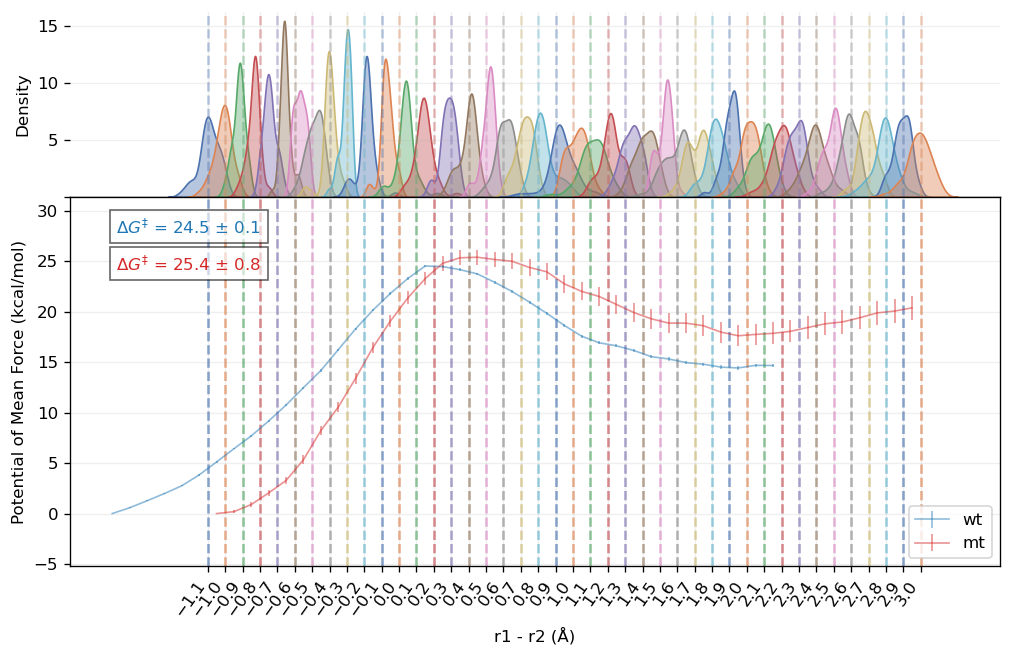

In [53]:

fig = plt.figure(figsize=(10,6), dpi=120)

# _Not for publication_

c = sb.color_palette('deep', n_windows) # color palette for windows
cpmf = ['tab:blue', 'tab:red']
_xfrac = 0.05
_yfrac = 0.9

opa = 0.4 # opacity

axs = fig.subplot_mosaic(
    """
    A
    B
    """,height_ratios=[1,2],sharex=True)

for i in range(n_windows):
    sb.kdeplot(val_kn[i], fill=True, alpha=opa, ax=axs['A'], color=c[i])
    axs['A'].axvline(x=val0_k[i], linestyle='--', alpha=opa, color=c[i])
    axs['A'].yaxis.get_major_ticks()[0].label1.set_visible(False)
    axs['A'].grid(linestyle='-', alpha=opa-0.2)

for idx in range(len(fnames)):
    xdata,ydata,yerrs,dgd,err = getpmf(fnames[idx])
    axs['B'].errorbar(xdata, ydata, yerr=yerrs, linewidth=1, color=cpmf[idx], alpha=opa+0.1,label=label[idx])
    for i in range(n_windows): 
        # axs['B'].scatter(xdata[i-1], ydata[i-1], color=c[i])
        axs['B'].axvline(x=val0_k[i], linestyle='--', alpha=opa, color=c[i])
        axs['B'].grid(linestyle='-', alpha=opa-0.2)

    axs['B'].annotate(f"$\Delta G^\ddag$ = {dgd} $\pm$ {err}", xy=(_xfrac,_yfrac), 
                        xycoords='axes fraction',bbox=dict(fc='w', alpha=opa+0.2), color=cpmf[idx])
    _yfrac=_yfrac-0.10

axs['B'].set_xlabel("r1 - r2 (Å)")
axs['B'].set_ylabel("Potential of Mean Force (kcal/mol)")

plt.legend(loc=4)
plt.margins(x=0.00, y=0.2)
plt.xticks(ticks=val0_k, rotation=55, ha='right')

sb.despine(left=True, bottom=False, right=True, ax=axs['A'])
fig.subplots_adjust(wspace=0, hspace=0)

plt.savefig(f"img/prelim-pmfref-{step}.{rep}.png")
plt.show()

In [43]:
# Copy notebook to templates directory

#!cp mbar.ipynb /home/van/github/amberassist/mbar/mbar.ipynb
#!jupyter-nbconvert /home/van/github/amberassist/mbar/mbar.ipynb --to python